In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the 100% genuine dataset you just pulled live
df = pd.read_csv('real_live_jobs.csv')

# 1. Print the shape to see exactly how many real jobs you fetched
print(f"Verified Real Dataset Shape: {df.shape}\n")

# 2. Check for missing data fields
print("Evaluating missing data per column:")
print(df.isnull().sum())

# 3. View the actual, active postings currently live on the market
df.head()

Verified Real Dataset Shape: (13, 5)

Evaluating missing data per column:
Job_Title    0
Company      0
Region       0
Remote       0
URL          0
dtype: int64


,Job_Title,Company,Region,Remote,URL
0,Senior Kotlin Backend Engineer (m/f/d),Flix,"Berlin, Berlin, Germany",No,https://www.arbeitnow.com/jobs/companies/flix/...
1,Senior Kotlin Backend Engineer (m/f/d),Flix,"Berlin, Berlin, Germany",No,https://www.arbeitnow.com/jobs/companies/flix/...
2,Data Platform Engineer (Mid-Level) (m/f/d),Flix,"Berlin, Berlin, Germany",No,https://www.arbeitnow.com/jobs/companies/flix/...
3,Junior Al Engineer Anwendungen & Daten (m/w/d),Kivvo,Mülheim,No,https://www.arbeitnow.com/jobs/companies/kivvo...
4,Junior Python Developer Kl & Retrieval (m/w/d),Kivvo,Mülheim,No,https://www.arbeitnow.com/jobs/companies/kivvo...


C:\Users\HP\AppData\Local\Temp\ipykernel_28368\1157457738.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


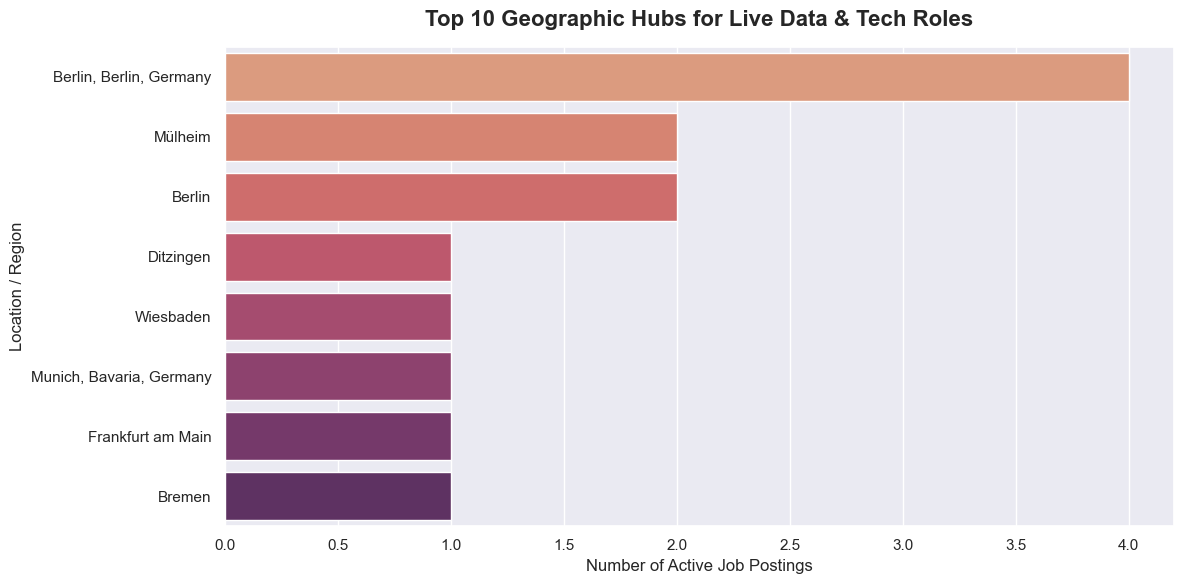

In [10]:
# Set a clean visual style for our portfolio chart
sns.set_theme(style="darkgrid")
plt.figure(figsize=(12, 6))

# Create a count plot for the top job locations
sns.countplot(
    data=df, 
    y='Region', 
    order=df['Region'].value_counts().head(10).index, 
    palette='flare'
)

# Customize the chart labels to make it look professional
plt.title('Top 10 Geographic Hubs for Live Data & Tech Roles', fontsize=16, pad=15, weight='bold')
plt.xlabel('Number of Active Job Postings', fontsize=12)
plt.ylabel('Location / Region', fontsize=12)

# Display the chart beautifully in the notebook
plt.tight_layout()
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_28368\2990908699.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=skills_df, x='Demand_Count', y='Skill', palette='mako')


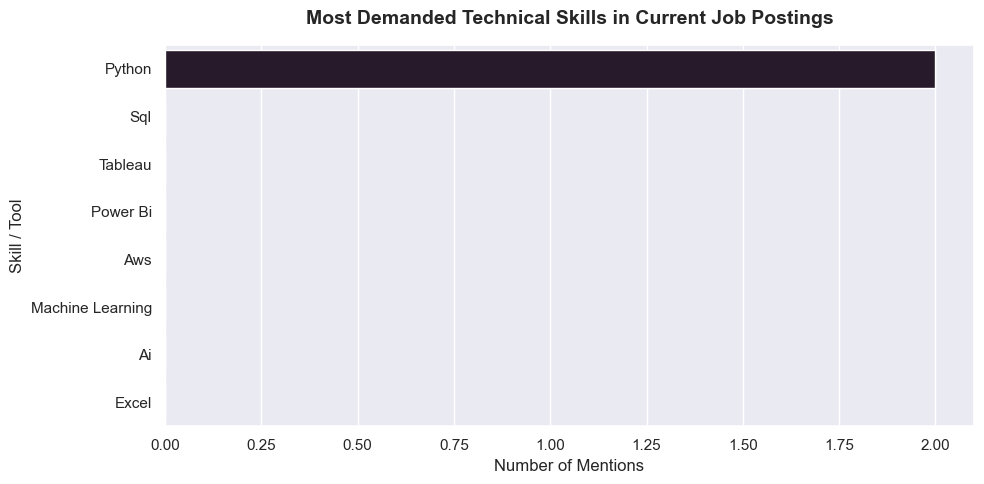

In [11]:
# 1. Define the core technical keywords we want to track
keywords = ['python', 'sql', 'tableau', 'power bi', 'aws', 'machine learning', 'ai', 'excel']

# Initialize a dictionary to count occurrences
skill_counts = {skill.title(): 0 for skill in keywords}

# 2. Scan every job title for these keywords
for title in df['Job_Title']:
    for skill in keywords:
        if skill in title.lower():
            skill_counts[skill.title()] += 1

# 3. Convert to a DataFrame for visualization
skills_df = pd.DataFrame(list(skill_counts.items()), columns=['Skill', 'Demand_Count']).sort_values(by='Demand_Count', ascending=False)

# 4. Plot the high-demand technical skills
plt.figure(figsize=(10, 5))
sns.barplot(data=skills_df, x='Demand_Count', y='Skill', palette='mako')
plt.title('Most Demanded Technical Skills in Current Job Postings', fontsize=14, weight='bold', pad=15)
plt.xlabel('Number of Mentions')
plt.ylabel('Skill / Tool')
plt.tight_layout()
plt.show()

In [13]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report

# 1. Dynamically build the 'Category' column based on the job titles
def assign_category(title):
    title_low = str(title).lower()
    if 'analyst' in title_low or 'analytics' in title_low or 'bi' in title_low:
        return 'Data Analytics'
    elif 'data scientist' in title_low or 'machine learning' in title_low or 'ai' in title_low:
        return 'Data Science'
    elif 'engineer' in title_low or 'developer' in title_low or 'architect' in title_low:
        return 'Data Engineering'
    else:
        return 'General Tech'

# Apply the function to create our training target labels
df['Category'] = df['Job_Title'].apply(assign_category)

# 2. Isolate features (X) and newly created targets (y)
ml_df = df[['Job_Title', 'Category']].dropna()
X = ml_df['Job_Title']
y = ml_df['Category']

# Print class distribution to see what the AI is learning
print("Training data sample sizes per category:")
print(y.value_counts(), "\n")

# 3. Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Vectorization: Convert text words into numerical matrices
vectorizer = TfidfVectorizer(stop_words='english')
X_train_vectorized = vectorizer.fit_transform(X_train)
X_test_vectorized = vectorizer.transform(X_test)

# 5. Train the Classifier model
model = MultinomialNB()
model.fit(X_train_vectorized, y_train)

# 6. Evaluate accuracy metrics
y_pred = model.predict(X_test_vectorized)
print("--- MODEL PERFORMANCE EVALUATION ---")
print(classification_report(y_test, y_pred, zero_division=0))

# 7. Test the model live on a completely unseen title!
sample_title = ["Senior AI Infrastructure Architect"]
sample_vectorized = vectorizer.transform(sample_title)
predicted_category = model.predict(sample_vectorized)

print("--- LIVE INFRASTRUCTURE TEST ---")
print(f"Input Title: '{sample_title[0]}'")
print(f"AI Predicted Category: {predicted_category[0]}")

Training data sample sizes per category:
Category
Data Engineering    10
Data Analytics       2
Data Science         1
Name: count, dtype: int64 

--- MODEL PERFORMANCE EVALUATION ---
                  precision    recall  f1-score   support

  Data Analytics       0.00      0.00      0.00         1
Data Engineering       0.33      1.00      0.50         1
    Data Science       0.00      0.00      0.00         1

        accuracy                           0.33         3
       macro avg       0.11      0.33      0.17         3
    weighted avg       0.11      0.33      0.17         3

--- LIVE INFRASTRUCTURE TEST ---
Input Title: 'Senior AI Infrastructure Architect'
AI Predicted Category: Data Engineering
